# Part B

# Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv("RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


# Identify Independent and Dependent Variable

In [6]:
print("Independent Variables (Features):")
features = ['House_Area', 'Bedrooms', 'Bathrooms', 'Location_Score', 'Age_of_Property']
for f in features:
    print(f"  • {f}")

print("\nDependent Variable (Target):")
print("  • House_Price")

print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
df.describe().round(2)

Independent Variables (Features):
  • House_Area
  • Bedrooms
  • Bathrooms
  • Location_Score
  • Age_of_Property

Dependent Variable (Target):
  • House_Price

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float6

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.00,4200.00,4200.00,4200.00,4200.00,4200.00,4200.00,4200.00,4200.00,4200.00,4200.00,4200.00
mean,102100.50,1667.36,3.70,2.83,5.61,23.83,18.19,3366.33,0.64,0.10,7.96,23641886.42
std,1212.58,630.34,1.57,1.15,2.14,13.95,8.67,1658.23,0.48,0.29,7.32,12392786.52
min,100001.00,450.00,1.00,1.00,1.00,1.00,1.00,800.00,0.00,0.00,0.00,800000.00
25%,101050.75,1226.75,3.00,2.00,4.00,13.00,11.80,2122.50,0.00,0.00,2.00,14259691.50
50%,102100.50,1660.00,4.00,3.00,5.70,21.00,17.80,3188.00,1.00,0.00,6.00,22145004.50
75%,103150.25,2084.25,5.00,4.00,7.30,32.00,24.20,4364.25,1.00,0.00,12.00,30960895.00
max,104200.00,4202.00,7.00,6.00,10.00,80.00,47.60,12938.00,1.00,1.00,50.00,76111718.00


# Visualize Relationships Between Features and Target

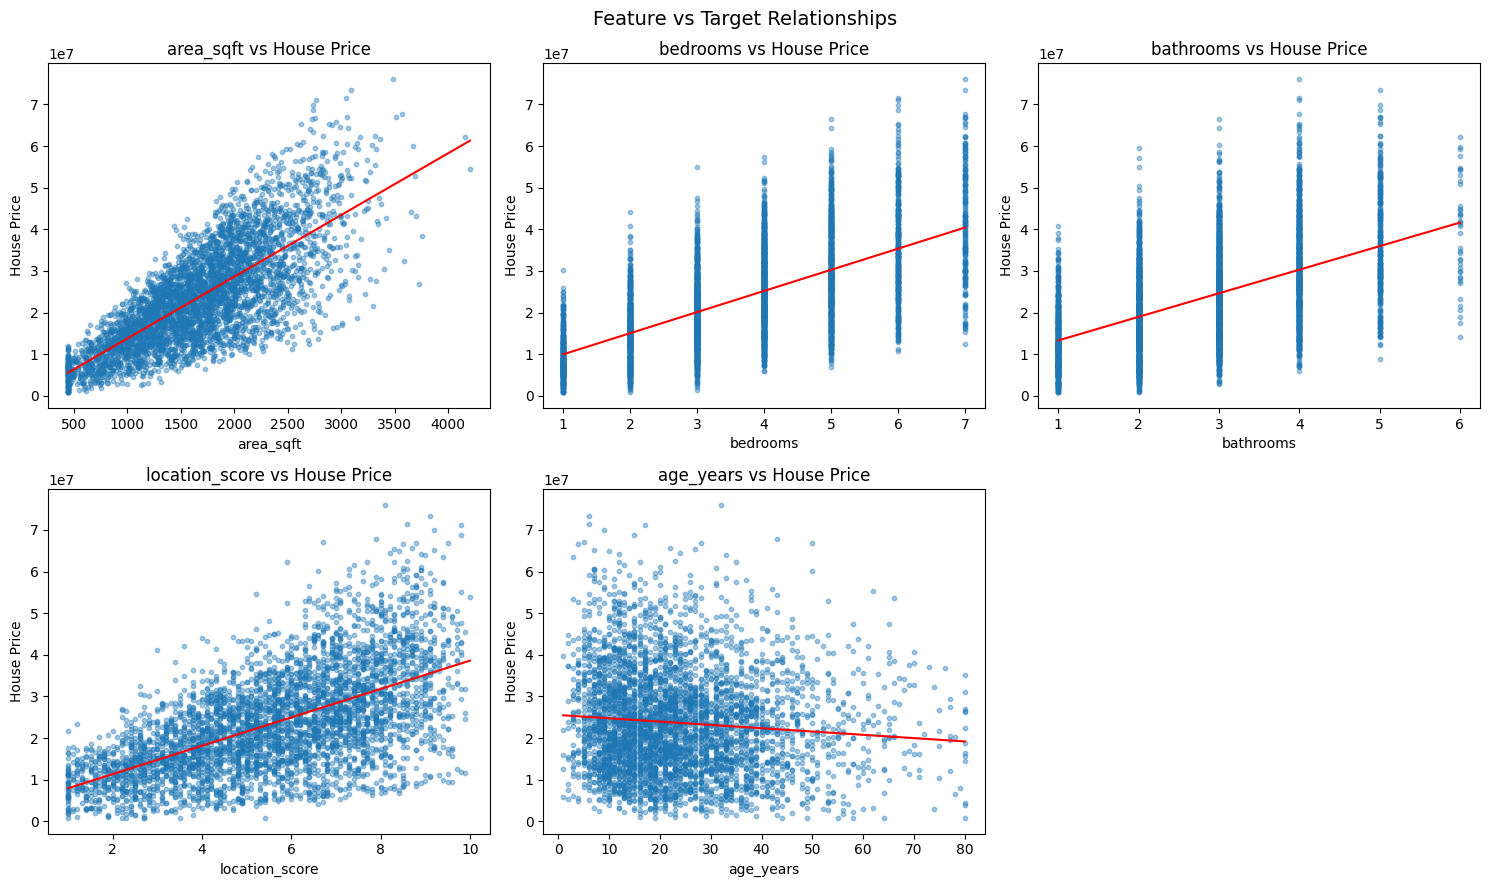

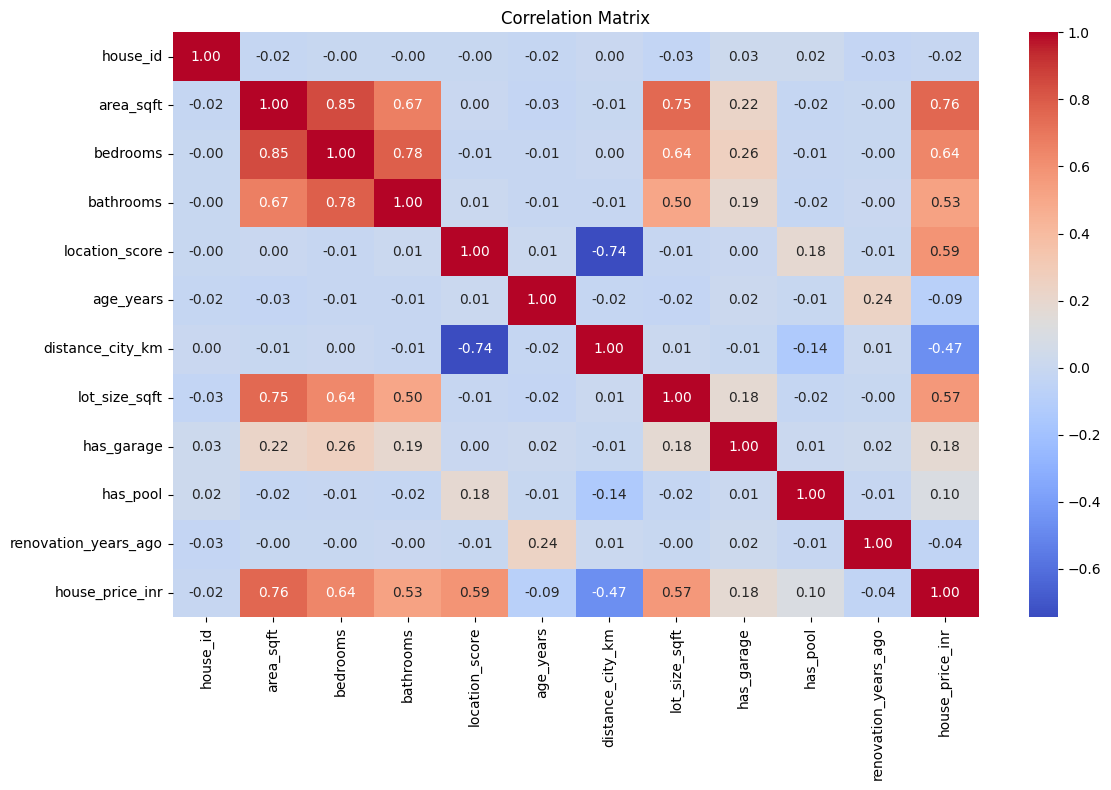

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['house_price_inr'], alpha=0.4, s=10)

    m, b = np.polyfit(df[feat], df['house_price_inr'], 1)

    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)

    axes[i].plot(x_line, m*x_line + b, color='red', linewidth=1.5)

    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("House Price")
    axes[i].set_title(f"{feat} vs House Price")

axes[-1].axis('off')

plt.suptitle("Feature vs Target Relationships", fontsize=14)
plt.tight_layout()
plt.show()


# Correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Regression plots were used to better understand the trend between features and house price. The red line represents the best-fit line, indicating the direction and strength of the relationship.

The correlation heatmap provides a comprehensive view of relationships between all variables. Strong positive correlations were observed between house price and features like area and location score, making them key predictors.

The visualizations reveal that certain features, particularly area and location score, have a strong influence on house prices. These insights are useful for selecting important variables in regression modeling.

# Train-Test Split

In [19]:
X = df[features]
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set size : {X_train.shape[0]} samples ({len(X_train)/len(df)*100:.0f}%)")
print(f"Testing  set size : {X_test.shape[0]} samples ({len(X_test)/len(df)*100:.0f}%)")
print("\nSample training features:")
X_train.head()

Training set size : 3360 samples (80%)
Testing  set size : 840 samples (20%)

Sample training features:


,area_sqft,bedrooms,bathrooms,location_score,age_years
2417,1871,6,4,6.4,6
3827,1967,4,3,7.6,15
239,2204,5,3,2.4,18
3633,2134,5,4,3.6,41
1543,1353,2,3,5.6,16


In [23]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3360, 11)
X_test shape: (840, 11)
y_train shape: (3360,)
y_test shape: (840,)


The dataset was divided into training and testing sets using an 80:20 ratio. The training set was used to train the regression model, while the testing set was used to evaluate its performance on unseen data. A random state of 42 was used to ensure reproducibility of results.

In [24]:
X_train

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago
2417,102418,1871,6,4,6.4,6,9.6,4867,1,0,0
3827,103828,1967,4,3,7.6,15,12.9,4347,1,0,15
239,100240,2204,5,3,2.4,18,22.0,5179,0,0,6
3633,103634,2134,5,4,3.6,41,21.5,3634,1,0,6
1543,101544,1353,2,3,5.6,16,25.7,2574,1,0,16
...,...,...,...,...,...,...,...,...,...,...,...
3444,103445,2102,5,4,3.8,77,24.2,4162,1,0,2
466,100467,2049,4,3,4.3,60,26.5,4248,1,0,23
3092,103093,1589,3,3,4.8,2,19.0,1687,0,0,0
3772,103773,1142,2,1,3.1,25,26.1,1798,1,0,1


In [25]:
y_train

2417    28039339
3827    36655898
239     19744745
3633    21812311
1543    19444280
          ...   
3444    19409041
466     23372689
3092    22461733
3772     8848343
860     21331055
Name: house_price_inr, Length: 3360, dtype: int64

In [26]:
X_test

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago
1743,101744,2405,4,2,6.6,11,10.1,3645,1,1,1
2196,102197,1927,4,3,6.7,7,24.9,5053,0,0,0
1728,101729,1889,5,4,2.5,11,37.0,4215,0,0,11
3337,103338,1553,2,3,8.2,11,8.4,3059,1,0,2
298,100299,2178,3,2,3.1,18,35.0,3459,0,0,17
...,...,...,...,...,...,...,...,...,...,...,...
152,100153,1208,2,2,9.2,39,12.2,2519,1,0,6
1948,101949,2382,4,4,7.3,5,18.9,4712,1,0,0
2751,102752,2672,7,5,2.6,7,34.9,6814,1,0,0
2148,102149,1583,3,2,5.1,36,25.0,4183,1,0,15


In [27]:
y_test

1743    36890986
2196    27836840
1728    15321534
3337    30812774
298     18194835
          ...   
152     20918771
1948    44375916
2751    22099538
2148    22898162
102     26744300
Name: house_price_inr, Length: 840, dtype: int64

Conclusion

In this part, the dataset was explored and prepared for model building using various exploratory data analysis techniques. Univariate, bivariate, and multivariate analyses were performed to understand the distribution of variables and their relationships with the target variable, house price.

The analysis revealed that features such as area, location score, and number of rooms have a significant influence on house prices, showing positive correlations. Irrelevant features like the identifier column were removed to improve data quality.

Outliers were identified and handled appropriately to reduce their impact on the dataset, ensuring more reliable model performance. Additionally, the dataset was split into training and testing sets to enable proper evaluation of machine learning models.

Overall, the dataset was found to be well-structured and suitable for regression analysis, with meaningful patterns that can be effectively used for predicting house prices.